# Policy Analysis (Sprint 1/2)

Quick sanity checks to see whether the learned policy adapts to workload signals.

## Setup

This notebook loads a saved Q-table, runs greedy rollouts to collect visited states, and then plots simple diagnostics to see if the policy is adaptive (not a full interpretability study).

In [28]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

c:\Users\rayan\OneDrive\Bureau\RL-Based-LLM-Inference\dynamic k


In [29]:
from __future__ import annotations

from pathlib import Path
import math

import matplotlib.pyplot as plt
import pandas as pd

from rl.controller import QLearningController
from simulation.env import TreeSpeculativeDecodingEnv
from state.features import featurize_state, initialize_state, K_VALUES

plt.style.use("seaborn-v0_8")

In [ ]:
# ---- Config ----
WORKLOAD_STYLE = "steady_low_load"
EPISODES = 200
EPISODE_LENGTH = 32
SEED = 7

ARTIFACT_CANDIDATES = [
    Path("..") / "artifacts" / "dynaq_table.json",
]

checkpoint_path = next((p for p in ARTIFACT_CANDIDATES if p.exists()), None)
if checkpoint_path is None:
    raise FileNotFoundError(
        "No Q-table found. Expected one of: " + 
        ", \n        ".join(str(p) for p in ARTIFACT_CANDIDATES)
    )

controller = QLearningController.load(str(checkpoint_path))
env = TreeSpeculativeDecodingEnv(
    workload_style=WORKLOAD_STYLE,
    episode_length=EPISODE_LENGTH,
    seed=SEED,
)

FEATURE_NAMES = [
    "feat_last_k",
    "feat_last_acceptance_bucket",
    "feat_ema_acceptance_bucket",
    "feat_rejection_bucket",
    "feat_prompt_bucket",
    "feat_generated_bucket",
    "feat_queue_bucket",
    "feat_batch_bucket",
    "feat_arrival_bucket",
    "feat_load_bucket",
    "feat_sla_bucket",
    "feat_branching_bucket",
]

def bucket_acceptance(value: float) -> int:
    if value < 0.35:
        return 0
    if value < 0.65:
        return 1
    return 2

def bucket_load(value: float) -> int:
    if value < 0.35:
        return 0
    if value < 0.70:
        return 1
    return 2

def bucket_queue(value: int) -> int:
    if value <= 2:
        return 0
    if value <= 6:
        return 1
    return 2

In [31]:
records = []
global_step = 0

for episode in range(EPISODES):
    state = env.reset()
    for step in range(EPISODE_LENGTH):
        action = controller.choose_k(state, greedy=True)
        next_state, reward, done, _info = env.step(state, action)

        feature_state = featurize_state(state)
        records.append(
            {
                "episode": episode,
                "step": step,
                "global_step": global_step,
                "action": action,
                "reward": reward,
                "raw_state": dict(state),
                "feature_state": feature_state,
            }
        )

        global_step += 1
        state = next_state
        if done:
            break

df = pd.DataFrame(records)
raw_df = pd.json_normalize(df["raw_state"]).add_prefix("raw.")
feat_df = pd.DataFrame(df["feature_state"].to_list(), columns=FEATURE_NAMES)
df = pd.concat([df, raw_df, feat_df], axis=1)

df["acceptance_bucket"] = df["raw.ema_acceptance_rate"].apply(bucket_acceptance)
df["load_bucket"] = df["raw.system_load"].apply(bucket_load)
df["queue_bucket"] = df["raw.queue_length"].apply(bucket_queue)

df.head()

,episode,step,global_step,action,reward,raw_state,feature_state,raw.last_k,raw.last_acceptance_rate,raw.ema_acceptance_rate,...,feat_generated_bucket,feat_queue_bucket,feat_batch_bucket,feat_arrival_bucket,feat_load_bucket,feat_sla_bucket,feat_branching_bucket,acceptance_bucket,load_bucket,queue_bucket
0,0,0,0,1,-1.949918,"{'last_k': 1, 'last_acceptance_rate': 0.55, 'e...","(1, 1, 1, 3, 1, 0, 0, 0, 0, 0, 2, 0)",1,0.55,0.550000,...,0,0,0,0,0,2,0,1,0,0
1,0,1,1,3,-6.227204,"{'last_k': 1, 'last_acceptance_rate': 0.0, 'em...","(1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 2, 1)",1,0.00,0.357500,...,0,0,1,0,0,2,1,1,0,0
2,0,2,2,4,1.130031,"{'last_k': 3, 'last_acceptance_rate': 0.0, 'em...","(3, 0, 0, 0, 1, 0, 0, 1, 0, 1, 2, 1)",3,0.00,0.232375,...,0,0,1,0,1,2,1,0,1,0
3,0,3,3,2,2.510881,"{'last_k': 4, 'last_acceptance_rate': 0.75, 'e...","(4, 2, 1, 2, 1, 0, 0, 0, 0, 2, 2, 0)",4,0.75,0.413544,...,0,0,0,0,2,2,0,1,2,0
4,0,4,4,2,1.935352,"{'last_k': 2, 'last_acceptance_rate': 1.0, 'em...","(2, 2, 1, 3, 1, 0, 0, 0, 0, 1, 2, 1)",2,1.00,0.618803,...,0,0,0,0,1,2,1,1,1,0


## Visited States Summary

We now have raw states, bucketed states, greedy actions, and rewards collected over many episodes.

In [32]:
df[["action", "reward", "acceptance_bucket", "load_bucket", "queue_bucket"]].describe()

,action,reward,acceptance_bucket,load_bucket,queue_bucket
count,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000
mean,2.387656,-1.195207,1.166719,0.898438,0.052969
std,1.375404,3.439197,0.734597,0.606263,0.242094
min,1.000000,-11.637140,0.000000,0.000000,0.000000
25%,1.000000,-3.638273,1.000000,1.000000,0.000000
50%,2.000000,-0.379465,1.000000,1.000000,0.000000
75%,3.000000,1.072097,2.000000,1.000000,0.000000
max,5.000000,7.349416,2.000000,2.000000,2.000000


## Policy Collapse Check

### A. Histogram of Chosen Actions

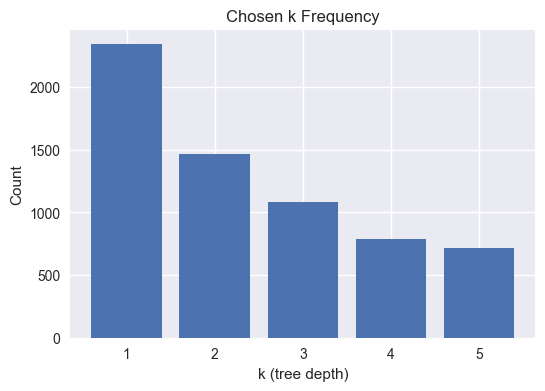

In [33]:
action_counts = df["action"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(action_counts.index.astype(str), action_counts.values)
plt.title("Chosen k Frequency")
plt.xlabel("k (tree depth)")
plt.ylabel("Count")
plt.show()

**Interpretation:** A strong spike at one k suggests collapse; a more spread distribution suggests adaptation across conditions.

### B. Action Frequency Over Time (Lightweight)

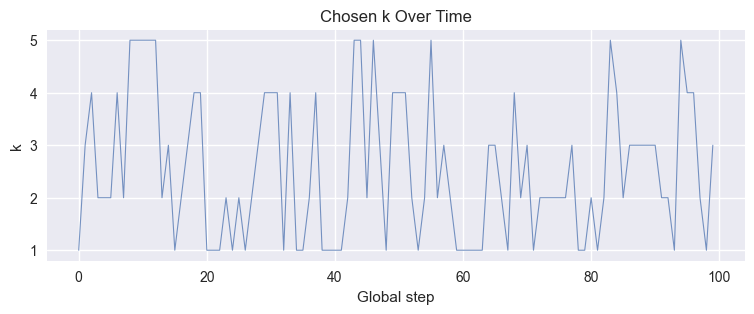

In [34]:
plt.figure(figsize=(9, 3))
plt.plot(df["global_step"].iloc[:100], df["action"].iloc[:100], linewidth=0.8, alpha=0.75)
plt.title("Chosen k Over Time")
plt.xlabel("Global step")
plt.ylabel("k")
plt.show()

## Main Policy Sanity Check (Most Important)

We visualize the greedy action as a function of only EMA acceptance rate bucket and system load bucket.

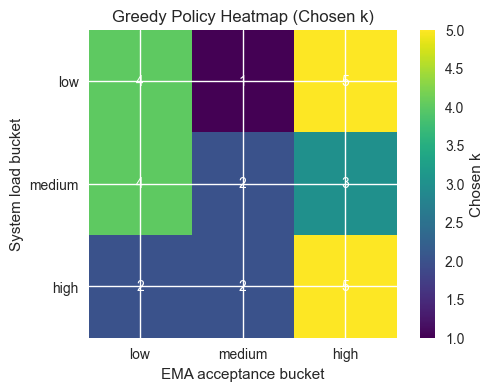

,low,medium,high
low,0.0,4.136574,6.866867
medium,0.0,0.000000,4.566623
high,0.0,0.000000,0.000000


In [35]:
acceptance_levels = {"low": 0.20, "medium": 0.50, "high": 0.80}
load_levels = {"low": 0.20, "medium": 0.55, "high": 0.85}

heatmap = []
max_q_map = []

for load_label, load_value in load_levels.items():
    row_actions = []
    row_q = []
    for acc_label, acc_value in acceptance_levels.items():
        state = initialize_state(WORKLOAD_STYLE)
        state["ema_acceptance_rate"] = acc_value
        state["last_acceptance_rate"] = acc_value
        state["system_load"] = load_value
        feature_state = featurize_state(state)

        action = controller.choose_k(state, greedy=True)
        q_values = controller.q_table.get(feature_state, {})
        max_q = max(q_values.values()) if q_values else float("nan")

        row_actions.append(action)
        row_q.append(max_q)
    heatmap.append(row_actions)
    max_q_map.append(row_q)

plt.figure(figsize=(6, 4))
plt.imshow(heatmap, cmap="viridis", vmin=min(K_VALUES), vmax=max(K_VALUES))
plt.colorbar(label="Chosen k")
plt.xticks(range(3), list(acceptance_levels.keys()))
plt.yticks(range(3), list(load_levels.keys()))
plt.xlabel("EMA acceptance bucket")
plt.ylabel("System load bucket")
plt.title("Greedy Policy Heatmap (Chosen k)")

for i in range(3):
    for j in range(3):
        plt.text(j, i, str(heatmap[i][j]), ha="center", va="center", color="white")

plt.show()

pd.DataFrame(max_q_map, index=load_levels.keys(), columns=acceptance_levels.keys())

**Interpretation:** Higher acceptance should generally allow larger k, while higher load should generally push k downward.

## Feature Influence Sanity Checks

We inspect average chosen k per bucket for a few key features.

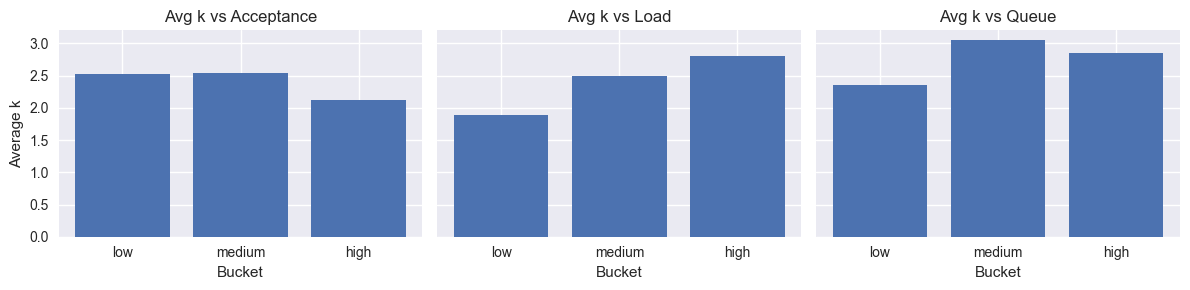

In [36]:
bucket_labels = {0: "low", 1: "medium", 2: "high"}

avg_by_acceptance = df.groupby("acceptance_bucket")["action"].mean()
avg_by_load = df.groupby("load_bucket")["action"].mean()
avg_by_queue = df.groupby("queue_bucket")["action"].mean()

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

axes[0].bar([bucket_labels[i] for i in avg_by_acceptance.index], avg_by_acceptance.values)
axes[0].set_title("Avg k vs Acceptance")

axes[1].bar([bucket_labels[i] for i in avg_by_load.index], avg_by_load.values)
axes[1].set_title("Avg k vs Load")

axes[2].bar([bucket_labels[i] for i in avg_by_queue.index], avg_by_queue.values)
axes[2].set_title("Avg k vs Queue")

for ax in axes:
    ax.set_xlabel("Bucket")
axes[0].set_ylabel("Average k")

plt.tight_layout()
plt.show()

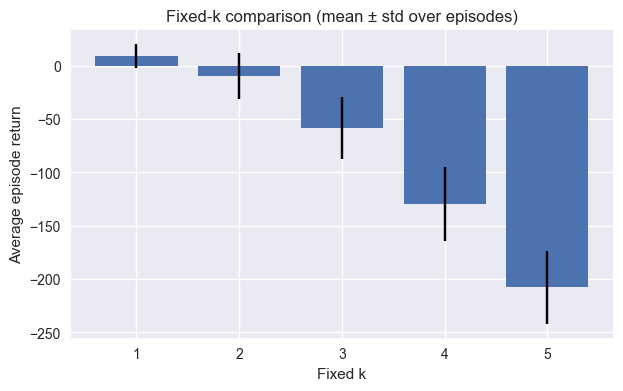

C:\Users\rayan\AppData\Local\Temp\ipykernel_25884\319044931.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([all_returns[k] for k in ks], labels=[str(k) for k in ks], showfliers=False)


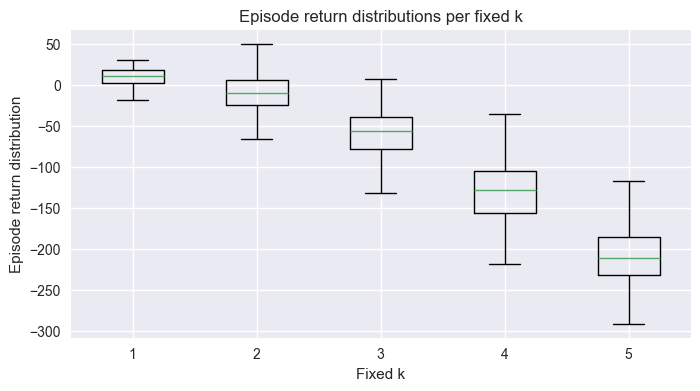

In [37]:
import numpy as np

# Fixed-k comparison: run EPISODES episodes for each k and plot average episode return with std

means = []
stds = []
all_returns = {}

for k in K_VALUES:
    env_k = TreeSpeculativeDecodingEnv(workload_style=WORKLOAD_STYLE, episode_length=EPISODE_LENGTH, seed=SEED)
    returns = []
    for ep in range(EPISODES):
        state = env_k.reset()
        ep_ret = 0.0
        for _ in range(EPISODE_LENGTH):
            next_state, reward, done, _ = env_k.step(state, k)
            ep_ret += reward
            state = next_state
            if done:
                break
        returns.append(ep_ret)
    all_returns[k] = returns
    means.append(np.mean(returns))
    stds.append(np.std(returns))

plt.figure(figsize=(7, 4))
ks = list(all_returns.keys())
plt.bar([str(k) for k in ks], means, yerr=stds, capsize=5)
plt.xlabel("Fixed k")
plt.ylabel("Average episode return")
plt.title("Fixed-k comparison (mean ± std over episodes)")
plt.show()

# Optional: show boxplot for distribution per k
plt.figure(figsize=(8, 4))
plt.boxplot([all_returns[k] for k in ks], labels=[str(k) for k in ks], showfliers=False)
plt.xlabel("Fixed k")
plt.ylabel("Episode return distribution")
plt.title("Episode return distributions per fixed k")
plt.show()